# Leapfrog Integration of a Bouncing Ball — Discontinuous vs. Smoothed Force

**Thomas Griffiths** — University of Washington Astronomy Department

This notebook is the second test model (after an earlier harmonic-oscillator
notebook) in a broader study of how the standard second-order leapfrog
integrator handles **discontinuous forces** — motivated by applications to
self-interacting dark matter simulations, where particle interactions can
involve abrupt force transitions. It precedes the development of the
velocity- and timestep-correction methods described in *Correction Methods
to Leapfrog Numerical Integrator*, which are implemented and tested in a
separate, larger notebook not included here.

A ball bouncing under gravity is modeled with two different force laws:

- **Absolute-value force** — `force(x) = -g * sign(x)`, a true discontinuity
  at $x=0$ (the "floor"), the idealized case.
- **Arctangent force** — `force(x) = -g * (2/π) * arctan(x/x_s)`, a smoothed
  approximation where the scale factor $x_s$ controls how sharp the
  transition is; $x_s \to 0$ recovers the discontinuous case, while larger
  $x_s$ approaches a smooth, continuous restoring force.

Only the **standard, uncorrected** leapfrog integrator is used throughout —
this notebook's purpose is to characterize the problem (drift, convergence
order, energy conservation) that the correction methods are later built to
address.

## What's in this notebook
1. **Standard leapfrog with the absolute-value force** — position, velocity,
   energy, and phase-space trajectories for the purely discontinuous case.
2. **Arctangent force** — same integration with a smoothed force, plus its
   exact potential energy expression (so total energy can be tracked).
3. **Solutions comparison** — the coarse leapfrog solution checked against a
   much higher-resolution leapfrog run (used as a stand-in reference/"exact"
   solution) for both position and velocity.
4. **Variable step size studies** — convergence of final/RMS error vs.
   stepsize (expected $O(h^2)$ scaling), energy-conservation behavior across
   a range of stepsizes and $x_s$ values, sensitivity of nearby trajectories
   in phase space (a basic stability/chaos check), and a cross-check against
   `scipy.integrate.solve_ivp` (RK45, tight tolerances) as an independent
   reference solution.
5. **Proper analytic solution** — for the discontinuous (absolute-value)
   case, a closed-form analytic position/velocity solution is derived and
   compared directly against the leapfrog numerical solution, including a
   final stepsize-vs-error convergence check against this true analytic
   reference rather than the earlier high-resolution numerical stand-in.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as const
import pandas as pd


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


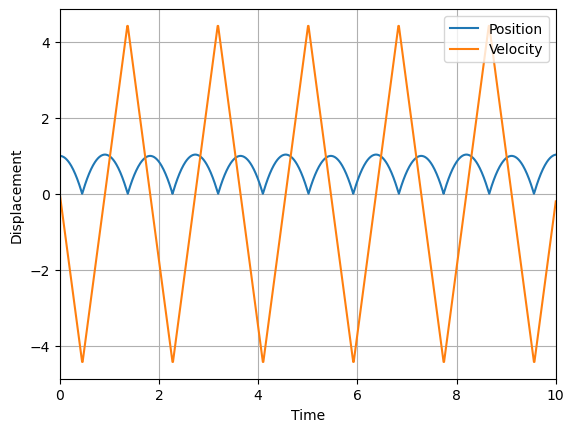

In [3]:
N = 1000
t = np.linspace(0,10,N) 
dt = t[1]-t[0]

x0 = 1
v0 = 0

def force(x):
     return -const.g * np.sign(x)

def leapfrog(x0, v0, dt, N):
    x = np.zeros(N)
    v = np.zeros(N)

    x[0] = x0
    v[0] = v0

    for i in range (N-1):
       
         v[i+1] = v[i] + 0.5 * dt * force(x[i])
         x[i+1] = x[i] + dt * v[i+1]
         v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1])

    return x,v

x, v = leapfrog(x0, v0, dt, N)

plt.figure()
plt.plot(t, np.abs(x), label = 'Position')
plt.plot(t, v, label = 'Velocity')
plt.xlim(0, 10)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.legend()
plt.grid()
plt.show()

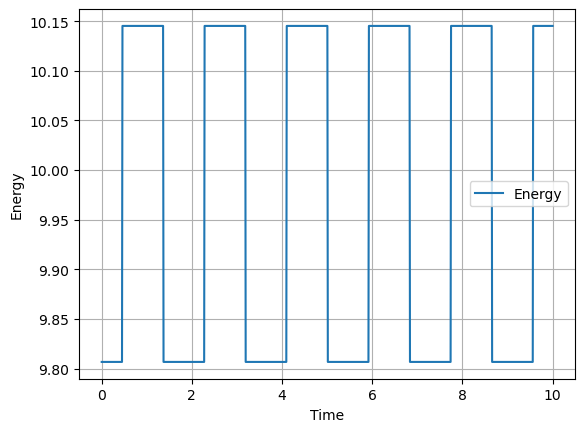

In [4]:
H = 0.5 * v **2 + const.g * np.abs(x)

plt.figure()
plt.plot(t, H, label = 'Energy')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.legend()
plt.grid()
plt.show()

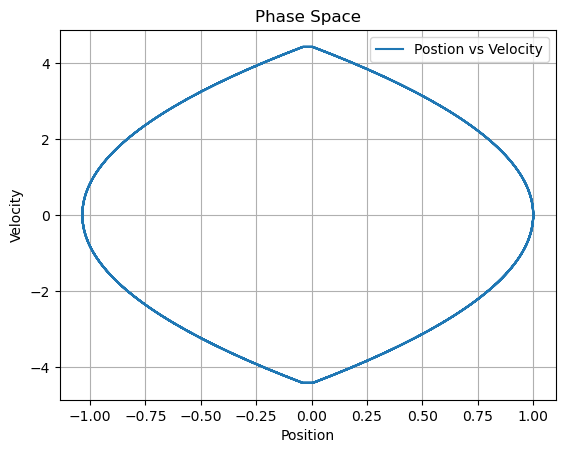

In [5]:
plt.figure()
plt.plot(x, v, label = 'Postion vs Velocity')
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space')
plt.legend()
plt.grid()
plt.show()

## New Force

Introducing the smoothed arctangent force in place of the discontinuous
absolute-value force. The cell below also derives and tracks the
corresponding potential energy term analytically (integrating the arctangent
force), so total energy $H = \frac{1}{2}v^2 + U(x)$ can be monitored
directly rather than only inferred from `np.abs(x)` as in the discontinuous
case above.

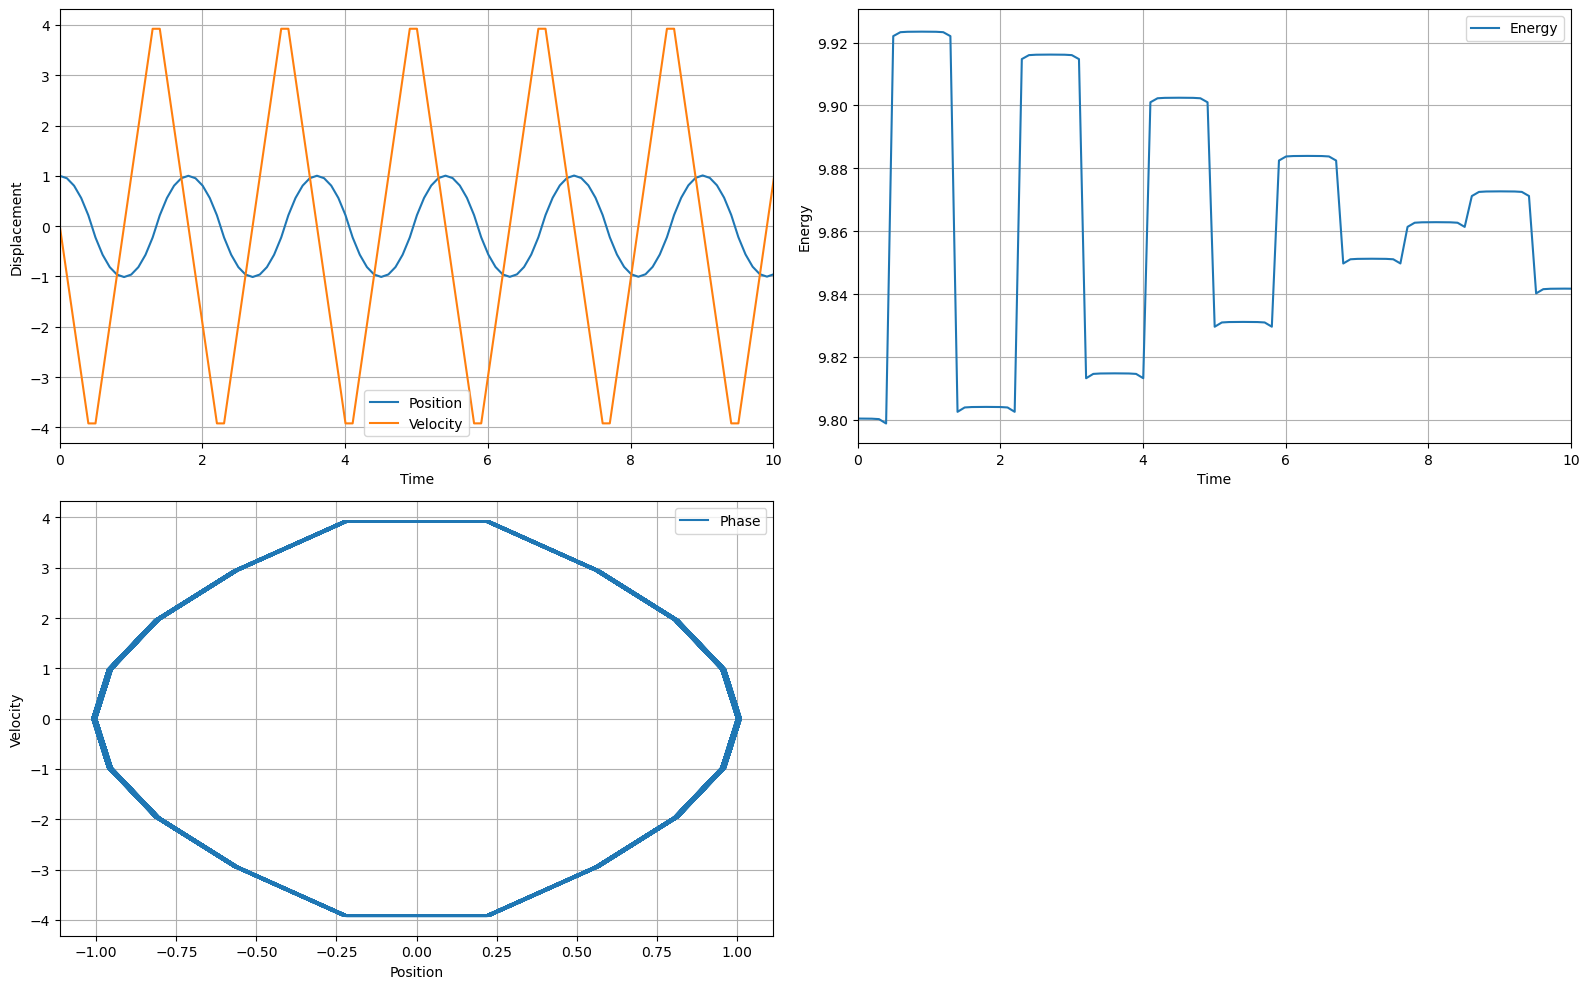

In [6]:
N = 1000
t = np.linspace(0,100,N) 
dt = t[1]-t[0]

x0 = 1
v0 = 0
x_s = 0.001

def force(x, x_s):
    return -const.g * 2/np.pi * np.arctan(x/x_s)

def leapfrog(x0, v0, x_s, dt, N):
    x = np.zeros(N)
    v = np.zeros(N)

    x[0] = x0
    v[0] = v0

    for i in range(N-1):
        v[i+1] = v[i] + 0.5 * dt * force(x[i], x_s)
        x[i+1] = x[i] + dt * v[i+1]
        v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1], x_s) 
    return x,v



x, v = leapfrog(x0, v0, x_s, dt, N)

H = 0.5 * v**2 + 2*const.g/np.pi * (x* np.arctan(x/x_s) - 0.5 * x_s * np.log(x**2 + x_s**2))
#H = 0.5 * v**2 + -2 * const.g/(np.pi * (1 + x**2/x_s**2) * x_s)

plt.figure(figsize=(16, 10))

plt.subplot(2,2,1)
plt.plot(t, x, label = 'Position')
plt.plot(t, v, label = 'Velocity')
plt.xlim(0, 10)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.legend()
plt.grid()

plt.subplot(2,2,2)
plt.plot(t, H, label = 'Energy')
plt.xlabel('Time')
plt.xlim(0, 10)
plt.ylabel('Energy')
plt.legend()
plt.grid()

plt.subplot(2,2,3)
plt.plot(x, v, label = 'Phase')
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Solutions Comparison

Here the standard leapfrog solution at a normal resolution is compared
against the *same* integrator run at much finer resolution
(`estimated_analytical_solution`) — this finer run is used as a practical
stand-in reference rather than a true closed-form solution, since no
analytic solution for the arctangent-force case is used here (that's
reserved for the absolute-value case further down, see "Proper Analytic").
The two are interpolated onto a common time grid so their difference can be
plotted directly.

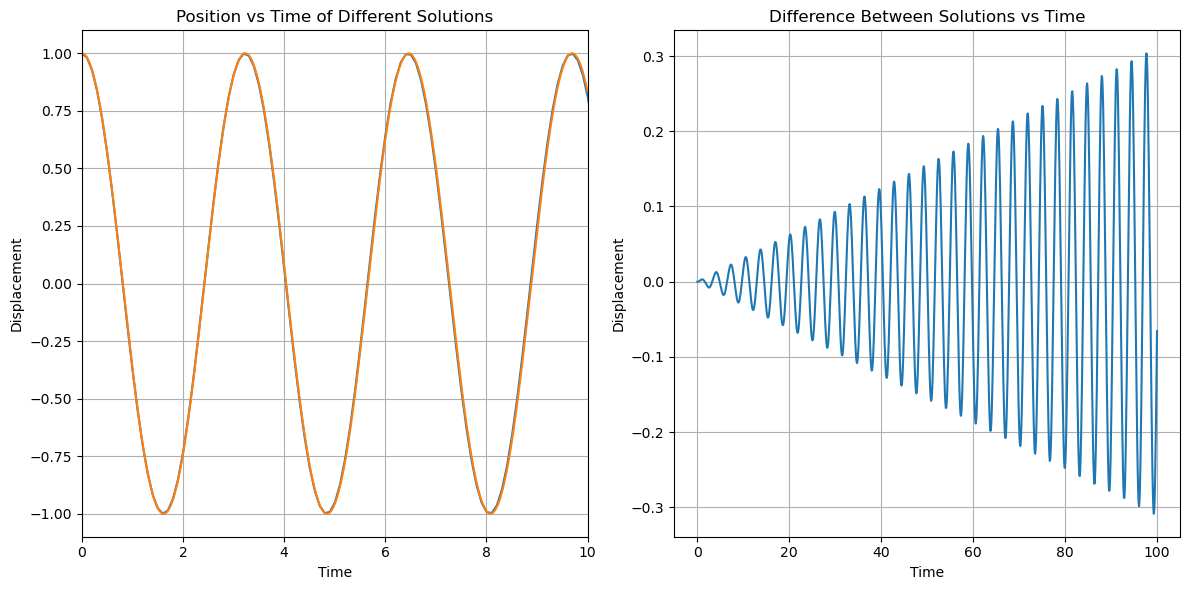

In [7]:
# Parameters
x0 = 1
v0 = 0
x_s = 1.5

def force(x, x_s):
    return -const.g * 2/np.pi * np.arctan(x/x_s)


def numerical_solution(x0, v0, x_s):
    N = 1000
    t = np.linspace(0,100,N) 
    dt = t[1]-t[0]
    
    x = np.zeros(N)
    v = np.zeros(N)

    x[0] = x0
    v[0] = v0

    for i in range (N-1):
       
         v[i+1] = v[i] + 0.5 * dt * force(x[i],x_s)
         x[i+1] = x[i] + dt * v[i+1]
         v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1],x_s)

    return t, x, v

def estimated_analytical_solution(x0, v0, x_s):
    N = 100000
    t = np.linspace(0,100,N)
    dt = t[1]-t[0]

    x = np.zeros(N)
    v = np.zeros(N)

    x[0] = x0
    v[0] = v0

    for i in range (N-1):
       
         v[i+1] = v[i] + 0.5 * dt * force(x[i],x_s)
         x[i+1] = x[i] + dt * v[i+1]
         v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1],x_s)

    return t, x ,v

t_numerical, x_numerical, v_numerical = numerical_solution(x0, v0, x_s)
t_estimate, x_estimate, v_estimate = estimated_analytical_solution(x0, v0, x_s)

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.plot(t_numerical, x_numerical, label = 'Numerical Position')
plt.plot(t_estimate, x_estimate, label = 'Estimated Analytic Position')
plt.xlabel('Time')
plt.xlim(0, 10)
plt.ylabel('Displacement')
plt.title('Position vs Time of Different Solutions')
plt.grid()

from scipy.interpolate import interp1d # Interpolates the data for the estimate as their is a dimensional difference for the time as it uses the different stepsizes.
x_estimate_interp = interp1d(t_estimate, x_estimate)(t_numerical)

plt.subplot(1,2,2)
plt.plot(t_numerical, x_estimate_interp - x_numerical)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Difference Between Solutions vs Time')
plt.grid()

plt.tight_layout()
plt.show()

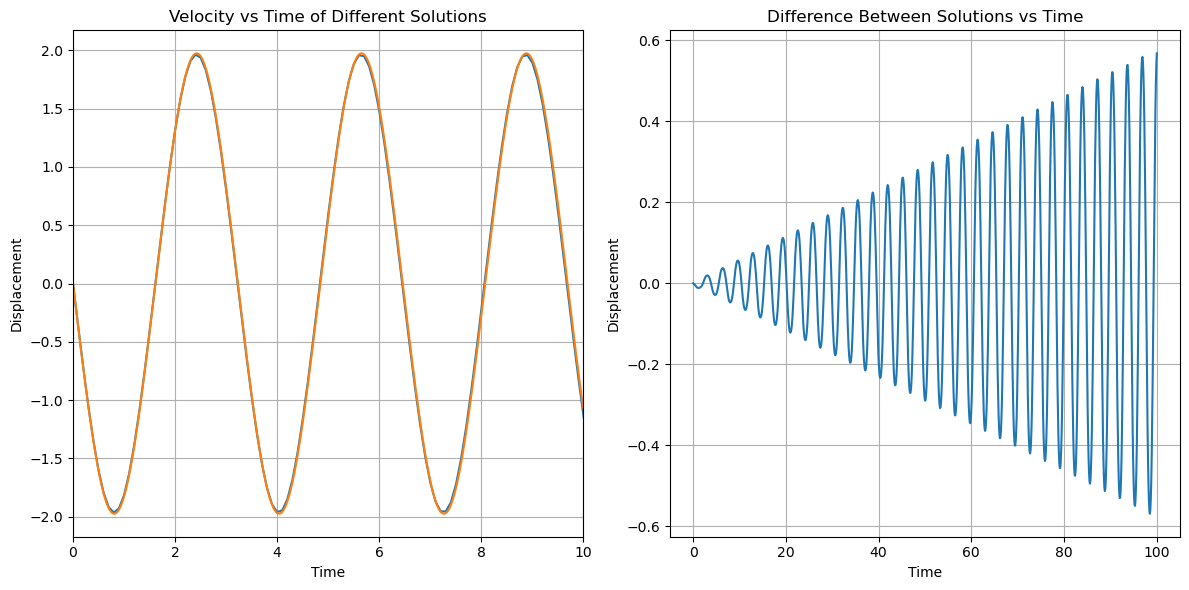

In [8]:
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.plot(t_numerical, v_numerical, label = 'Numerical Velocity')
plt.plot(t_estimate, v_estimate, label = 'Estimated Analytic Velocity')
plt.xlabel('Time')
plt.xlim(0, 10)
plt.ylabel('Displacement')
plt.title('Velocity vs Time of Different Solutions')
plt.grid()

v_estimate_interp = interp1d(t_estimate, v_estimate)(t_numerical)

plt.subplot(1,2,2)
plt.plot(t_numerical, v_estimate_interp - v_numerical)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Difference Between Solutions vs Time')
plt.grid()

plt.tight_layout()
plt.show()

# Variable Step Size

The remaining cells in this section study how integration accuracy and
energy conservation scale with stepsize and with the force's sharpness
($x_s$): final/RMS position and velocity error vs. stepsize (checked against
the expected $h^2$ convergence), energy drift across a stepsize/$x_s$ grid,
a phase-space sensitivity test comparing two trajectories with a tiny
initial-position perturbation, and an independent cross-check against
`scipy.integrate.solve_ivp`.The cells below study integration accuracy for the **arctangent force**
across a range of stepsizes and scale-factor values:

- **Convergence** (`x_s = 1`, coarse vs. fine high-resolution reference) —
  final and RMS position/velocity error vs. stepsize, checked against the
  expected $h^2$ scaling.
- **Energy conservation** (`x_s = 0.01`, sharper discontinuity) — how energy
  drift varies with stepsize when the force transition is near-discontinuous.
- **Error accumulation** (`x_s = 0.1`) — how a tiny perturbation in initial
  position ($\delta x_0 = 10^{-6}$) grows over time; a measure of how quickly
  nearby trajectories diverge under this integrator and force law.
- **IVP cross-check** (`x_s = 1`, vs. `scipy.integrate.solve_ivp` RK45 with
  tight tolerances) — an independent reference solution to validate the
  high-resolution numerical stand-in used above.

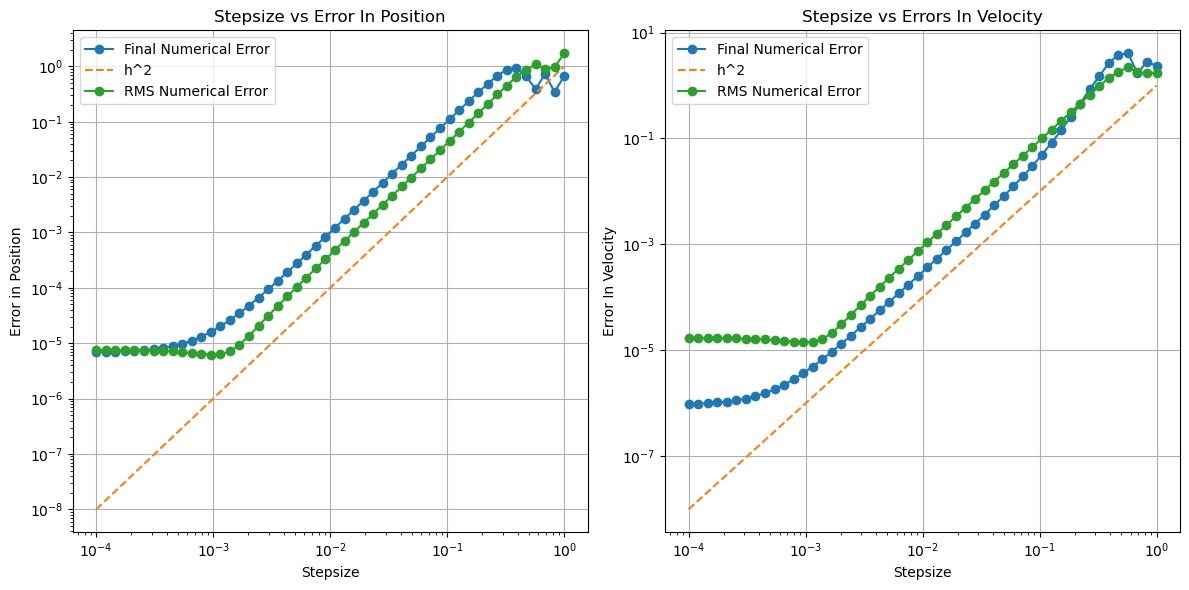

In [9]:
# Parameters
orbits = 10
x0 = 1
v0 = 0
x_s = 1
T = 2 * np.pi * np.sqrt(x0/const.g) #Time Orbit

def force(x, x_s):
    return -const.g * 2 / np.pi * np.arctan(x / x_s)

def numerical_solution(x0, v0, x_s, dt, T, orbits):
    t_final = orbits * T
    h = int(t_final / dt) + 1
    t = np.linspace(0, t_final, h)
    dt = t_final/(h-1)
    
    x = np.zeros(h)
    v = np.zeros(h)

    x[0] = x0
    v[0] = v0

    for i in range(h-1):
        v[i+1] = v[i] + 0.5 * dt * force(x[i], x_s)
        x[i+1] = x[i] + dt * v[i+1]
        v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1], x_s)

    return t, x, v


def estimated_analytical_solution(x0, v0, x_s, T, orbits):
    dt = 1e-5  #Reference Time Step
    t_final = orbits * T
    h = int(t_final / dt) + 1
    t = np.linspace(0, t_final, h)
    
    x = np.zeros(h)
    v = np.zeros(h)

    x[0] = x0
    v[0] = v0

    for i in range(h-1):
        v[i+1] = v[i] + 0.5 * dt * force(x[i], x_s)
        x[i+1] = x[i] + dt * v[i+1]
        v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1], x_s)

    return t, x, v

t_estimate, x_estimate, v_estimate = estimated_analytical_solution(x0, v0, x_s, T, orbits)

def find_closest_index(t_ref, t_target):
    # Find the index in t_ref that is closest to each value in t_target.
    return np.searchsorted(t_ref, t_target)

def calculate_error(stepsizes):
    final_error_position = []
    final_error_velocity = []
    rms_error_position = []
    rms_error_velocity = []
    
    for dt in stepsizes:
        t_numerical, x_numerical, v_numerical = numerical_solution(x0, v0, x_s, dt, T, orbits)

        closest_indices = find_closest_index(t_estimate, t_numerical)

        x_estimate_closest = x_estimate[closest_indices]
        v_estimate_closest = v_estimate[closest_indices]
        
        final_error_x = np.abs(x_estimate_closest - x_numerical)[-1]
        rms_error_x = np.sqrt(np.mean((x_estimate_closest - x_numerical)**2))
        final_error_position.append(final_error_x)
        rms_error_position.append(rms_error_x)

        final_error_v = np.abs(v_estimate_closest - v_numerical)[-1]
        rms_error_v = np.sqrt(np.mean((v_estimate_closest - v_numerical)**2))
        final_error_velocity.append(final_error_v)
        rms_error_velocity.append(rms_error_v)

    return final_error_position, rms_error_position, final_error_velocity, rms_error_velocity, t_numerical, x_numerical, v_numerical


# Step Sizes
stepsizes = np.logspace(-4,0,50)
final_error_position, rms_error_position, final_error_velocity, rms_error_velocity, t_numerical, x_numerical, v_numerical = calculate_error(stepsizes)

#Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(stepsizes, final_error_position, marker='o', label = 'Final Numerical Error')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.plot(stepsizes, rms_error_position, marker='o', label = 'RMS Numerical Error')
plt.xlabel('Stepsize')
plt.ylabel('Error in Position')
plt.title('Stepsize vs Error In Position')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(stepsizes, final_error_velocity, marker='o', label = 'Final Numerical Error')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle = 'dashed', label = 'h^2')
plt.plot(stepsizes, rms_error_velocity, marker='o', label = 'RMS Numerical Error')
plt.xlabel('Stepsize')
plt.ylabel('Error In Velocity')
plt.title('Stepsize vs Errors In Velocity')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/hn/_yk3p7wx40j2d5rpwxm35r1m0000gn/T/ipykernel_49638/1392500725.py:45: RuntimeWarning: divide by zero encountered in log
  energy_error = np.log(np.abs(energy - energy[0]))


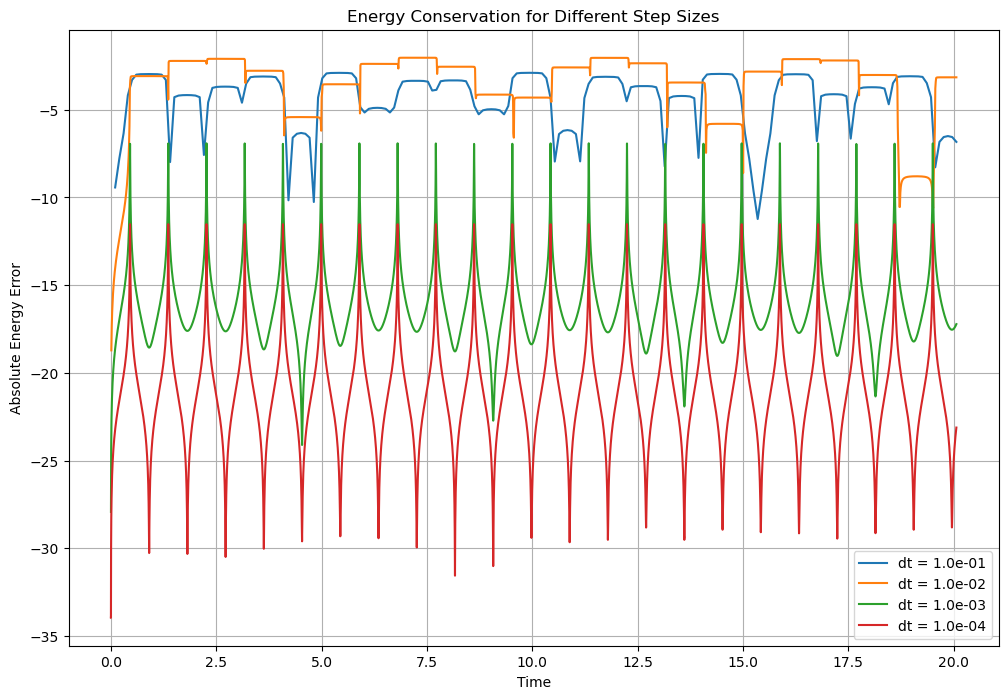

In [10]:
# Parameters
orbits = 10
x0 = 1
v0 = 0
x_s = 0.01
T = 2 * np.pi * np.sqrt(x0/const.g)  # Time per orbit

def force(x, x_s):
    return -const.g * 2 / np.pi * np.arctan(x / x_s)

def calculate_hamiltonian(x, v, x_s):
    kinetic = 0.5 * v**2
    potential = -const.g / np.pi * (np.log(x**2 + x_s**2) * x_s - 2 * x * np.arctan(x/x_s))
    return kinetic + potential

def numerical_solution(x0, v0, x_s, dt, T, orbits):
    t_final = orbits * T
    h = int(t_final / dt) + 1
    t = np.linspace(0, t_final, h)
    dt = t_final/(h-1)
    
    x = np.zeros(h)
    v = np.zeros(h)
    energy = np.zeros(h)

    x[0] = x0
    v[0] = v0
    energy[0] = calculate_hamiltonian(x[0], v[0], x_s)

    for i in range(h-1):
        v[i+1] = v[i] + 0.5 * dt * force(x[i], x_s)
        x[i+1] = x[i] + dt * v[i+1]
        v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1], x_s)
        energy[i+1] = calculate_hamiltonian(x[i+1], v[i+1], x_s)

    return t, x, v, energy

def plot_energy_conservation(stepsizes):
    plt.figure(figsize=(12, 8))
    
    for dt in stepsizes:
        t, x, v, energy = numerical_solution(x0, v0, x_s, dt, T, orbits)
        
        # Absolute Energy Error
        energy_error = np.log(np.abs(energy - energy[0]))
        
        plt.plot(t, energy_error, label=f'dt = {dt:.1e}')
    
    plt.xlabel('Time')
    plt.ylabel('Absolute Energy Error')
    plt.title('Energy Conservation for Different Step Sizes')
    plt.legend()
    plt.grid(True)
    plt.show()

def print_energy_stats(stepsizes):
    for dt in stepsizes:
        t, x, v, energy = numerical_solution(x0, v0, x_s, dt, T, orbits)
        energy_error = energy - energy[0]
        max_error = np.max(np.abs(energy_error))
        mean_error = np.mean(np.abs(energy_error))
        print(f"Step size: {dt:.1e}")
        print(f"  Initial energy: {energy[0]:.2e}")
        print(f"  Max absolute energy error: {max_error:.2e}")
        print(f"  Mean absolute energy error: {mean_error:.2e}")
        print()

stepsizes = [1e-1, 1e-2, 1e-3, 1e-4]
plot_energy_conservation(stepsizes)

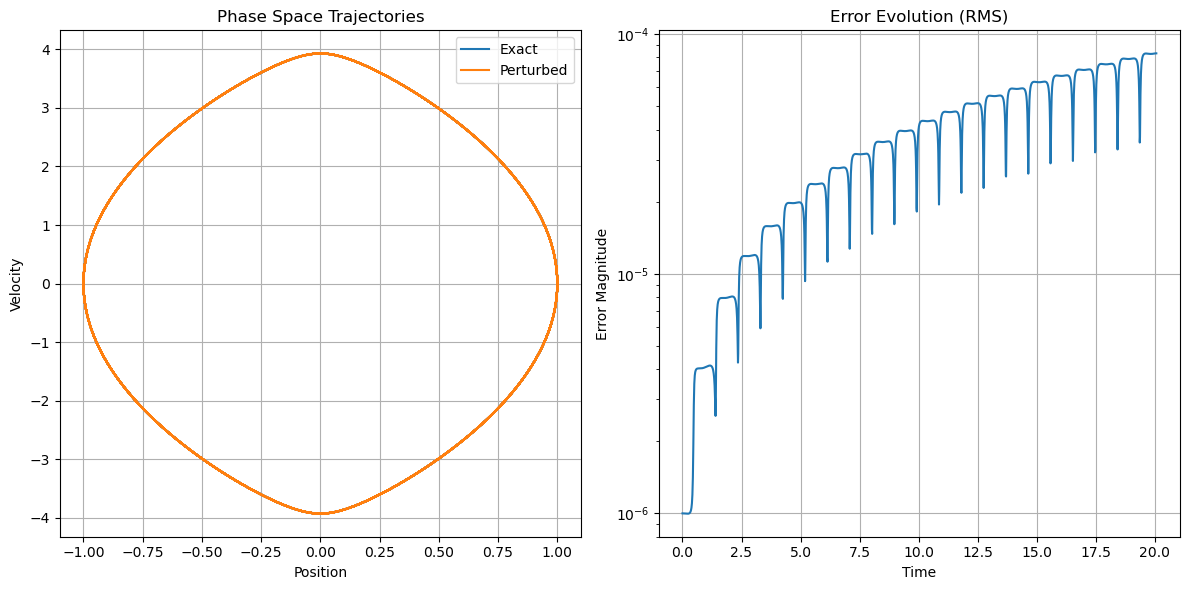

In [11]:
# Parameters
orbits = 10
x0 = 1
v0 = 0
x_s = 0.1
T = 2 * np.pi * np.sqrt(x0/const.g)  # Time per orbit

def force(x, x_s):
    return -const.g * 2 / np.pi * np.arctan(x / x_s)

def calculate_hamiltonian(x, v, x_s):
    kinetic = 0.5 * v**2
    potential = -const.g / np.pi * (np.log(x**2 + x_s**2) * x_s - 2 * x * np.arctan(x/x_s))
    return kinetic + potential

def numerical_solution(x0, v0, x_s, dt, T, orbits):
    t_final = orbits * T
    h = int(t_final / dt) + 1
    t = np.linspace(0, t_final, h)
    dt = t_final/(h-1)
    
    x = np.zeros(h)
    v = np.zeros(h)
    energy = np.zeros(h)

    x[0] = x0
    v[0] = v0
    energy[0] = calculate_hamiltonian(x[0], v[0], x_s)

    for i in range(h-1):
        v[i+1] = v[i] + 0.5 * dt * force(x[i], x_s)
        x[i+1] = x[i] + dt * v[i+1]
        v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1], x_s)
        energy[i+1] = calculate_hamiltonian(x[i+1], v[i+1], x_s)

    return t, x, v, energy


def phase_space_error(x0, v0, x_s, dt, orbits):
    t, x_exact, v_exact, _ = numerical_solution(x0, v0, x_s, dt, T, orbits)
    t, x_approx, v_approx, _ = numerical_solution(x0 + 1e-6, v0, x_s, dt, T, orbits)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(121)
    plt.plot(x_exact, v_exact, label='Exact')
    plt.plot(x_approx, v_approx, label='Perturbed')
    plt.xlabel('Position')
    plt.ylabel('Velocity')
    plt.title('Phase Space Trajectories')
    plt.grid()
    plt.legend()
    
    plt.subplot(122)
    plt.plot(t, np.sqrt((x_exact - x_approx)**2 + (v_exact - v_approx)**2))
    plt.xlabel('Time')
    plt.ylabel('Error Magnitude')
    plt.title('Error Evolution (RMS)')
    plt.yscale('log')
    plt.grid()
    plt.tight_layout()
    plt.show()

phase_space_error(x0, v0, x_s, 0.01, 10)

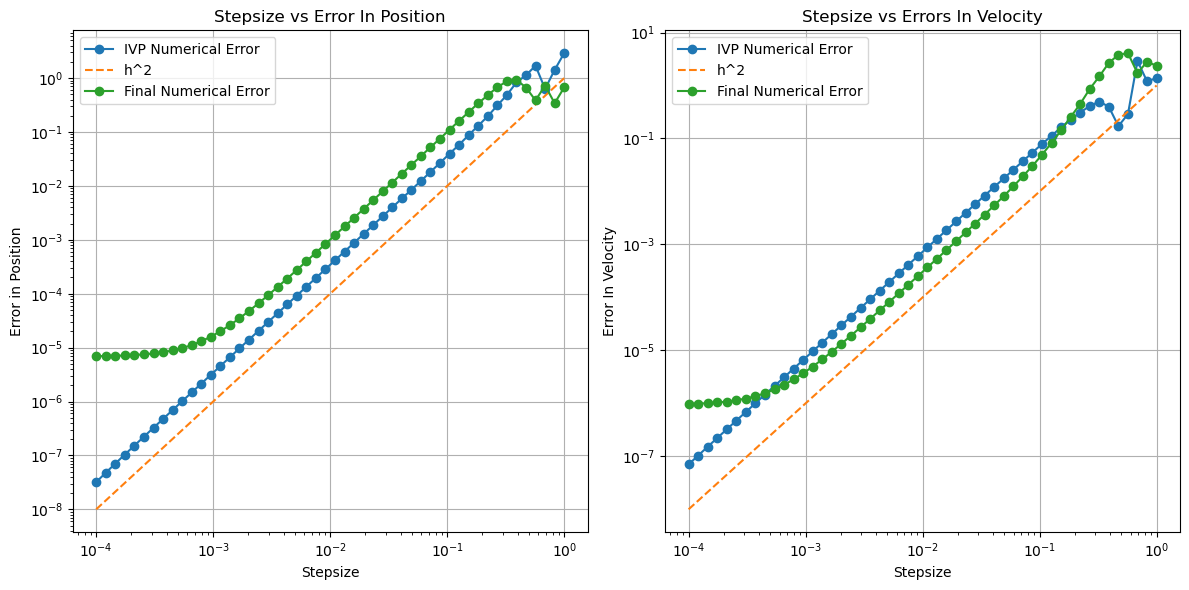

In [12]:
from scipy.integrate import solve_ivp

# Parameters
orbits = 5
x0 = 1
v0 = 0
x_s = 1
T = 2 * np.pi * np.sqrt(x0/const.g)  # Time Orbit

def force(x, x_s):
    return -const.g * 2 / np.pi * np.arctan(x / x_s)

def numerical_solution(x0, v0, x_s, dt, T, orbits):
    t_final = orbits * T
    h = int(t_final / dt) + 1
    t = np.linspace(0, t_final, h)
    dt = t_final/(h-1)
    
    x = np.zeros(h)
    v = np.zeros(h)
    x[0] = x0
    v[0] = v0
    for i in range(h-1):
        v[i+1] = v[i] + 0.5 * dt * force(x[i], x_s)
        x[i+1] = x[i] + dt * v[i+1]
        v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1], x_s)
    return t, x, v

def system(t, y, x_s):
    x, v = y
    return [v, force(x, x_s)]

def ivp_solution(x0, v0, x_s, T, orbits):
    t_span = (0, orbits * T)
    y0 = [x0, v0]
    sol = solve_ivp(system, t_span, y0, args=(x_s,), method='RK45', rtol=1e-10, atol=1e-10)
    return sol.t, sol.y[0], sol.y[1]

def find_closest_index(t_ref, t_target):
    return np.searchsorted(t_ref, t_target)

def calculate_error(stepsizes):
    t_ref, x_ref, v_ref = ivp_solution(x0, v0, x_s, T, orbits)
    
    ivp_error_position = []
    ivp_error_velocity = []
    
    for dt in stepsizes:
        t_numerical, x_numerical, v_numerical = numerical_solution(x0, v0, x_s, dt, T, orbits)
        closest_indices = find_closest_index(t_ref, t_numerical)
        x_ref_closest = x_ref[closest_indices]
        v_ref_closest = v_ref[closest_indices]
        
        error_x = np.abs(x_ref_closest - x_numerical)[-1]
        ivp_error_position.append(error_x)
        error_v = np.abs(v_ref_closest - v_numerical)[-1]
        ivp_error_velocity.append(error_v)
    
    return ivp_error_position, ivp_error_velocity, t_numerical, x_numerical, v_numerical

# Step Sizes
stepsizes = np.logspace(-4, 0, 50)
ivp_error_position, ivp_error_velocity, t_numerical, x_numerical, v_numerical = calculate_error(stepsizes)

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(stepsizes, ivp_error_position, marker='o', label='IVP Numerical Error')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle='dashed', label='h^2')
plt.plot(stepsizes, final_error_position, marker='o', label = 'Final Numerical Error')
plt.xlabel('Stepsize')
plt.ylabel('Error in Position')
plt.title('Stepsize vs Error In Position')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(stepsizes, ivp_error_velocity, marker='o', label='IVP Numerical Error')
plt.plot(stepsizes, np.array(stepsizes)**2, linestyle='dashed', label='h^2')
plt.plot(stepsizes, final_error_velocity, marker='o', label = 'Final Numerical Error')
plt.xlabel('Stepsize')
plt.ylabel('Error In Velocity')
plt.title('Stepsize vs Errors In Velocity')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

# Proper Analytic

Unlike the arctangent force, the purely discontinuous absolute-value
bouncing ball has a true closed-form analytic solution — the particle follows
piecewise parabolas between bounces, giving exact position and velocity
expressions in terms of $\arcsin(\sin(t))$ (a triangular wave). This is used
as a genuine ground truth rather than a high-resolution numerical stand-in.

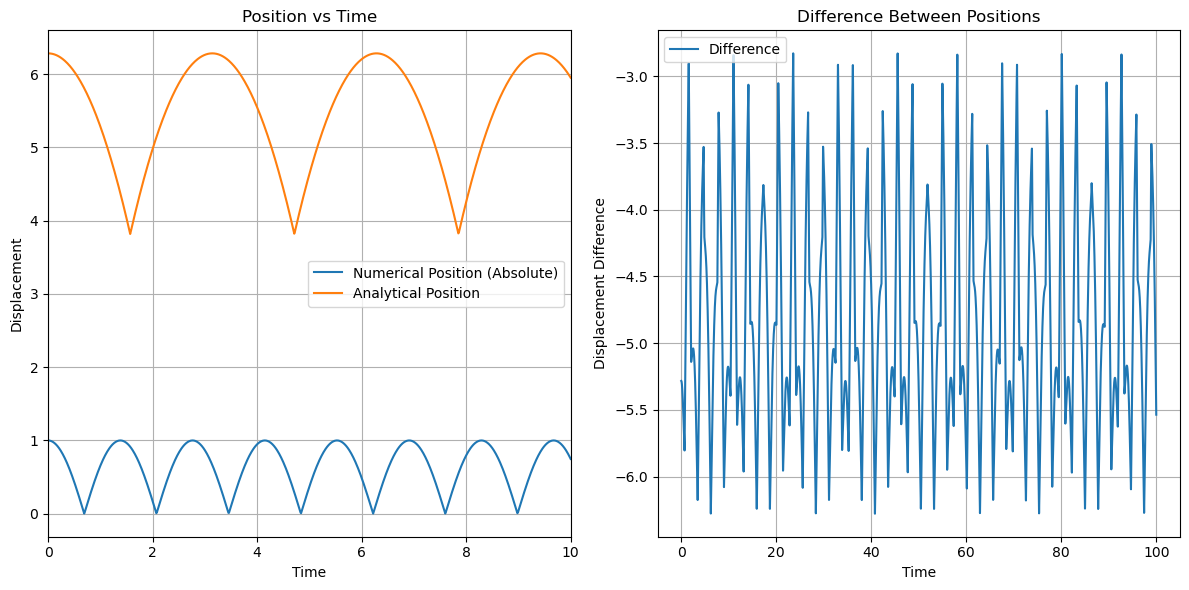

In [13]:
N = 10000
t = np.linspace(0,100,N) 
dt = t[1]-t[0]

x0 = 1
v0 = 0
x_s = 1


def analytic(t):
    v = -(2 * np.cos(t) * np.arcsin(np.sin(t)))/(np.sqrt(1-np.sin(t)**2))
    x = (2 * np.pi - np.arcsin(np.sin(t))**2)
    #x = (x - np.min(x)) / (np.max(x) - np.min(x))  # Normalize x
    #v = (v - np.min(v)) / (np.max(v) - np.min(v))  # Normalize v
    return x,v

def force(x, x_s):
    return -const.g * 2/np.pi * np.arctan(x/x_s)

def numeric(x0, v0, x_s, dt, N):
    x = np.zeros(N)
    v = np.zeros(N)

    x[0] = x0
    v[0] = v0

    for i in range (N-1):
       
         v[i+1] = v[i] + 0.5 * dt * force(x[i],x_s)
         x[i+1] = x[i] + dt * v[i+1]
         v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1],x_s)

    return x,v

x_numeric, v_numeric = numeric(x0, v0, x_s, dt, N)
x_analytic, v_analytic = analytic(t)

#Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(t, np.abs(x_numeric), label='Numerical Position (Absolute)')
plt.plot(t, x_analytic, label='Analytical Position')
plt.xlabel('Time')
plt.xlim(0,10)
plt.ylabel('Displacement')
plt.title('Position vs Time')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, np.abs(x_numeric) - x_analytic, label='Difference')
plt.xlabel('Time')
plt.ylabel('Displacement Difference')
plt.title('Difference Between Positions')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


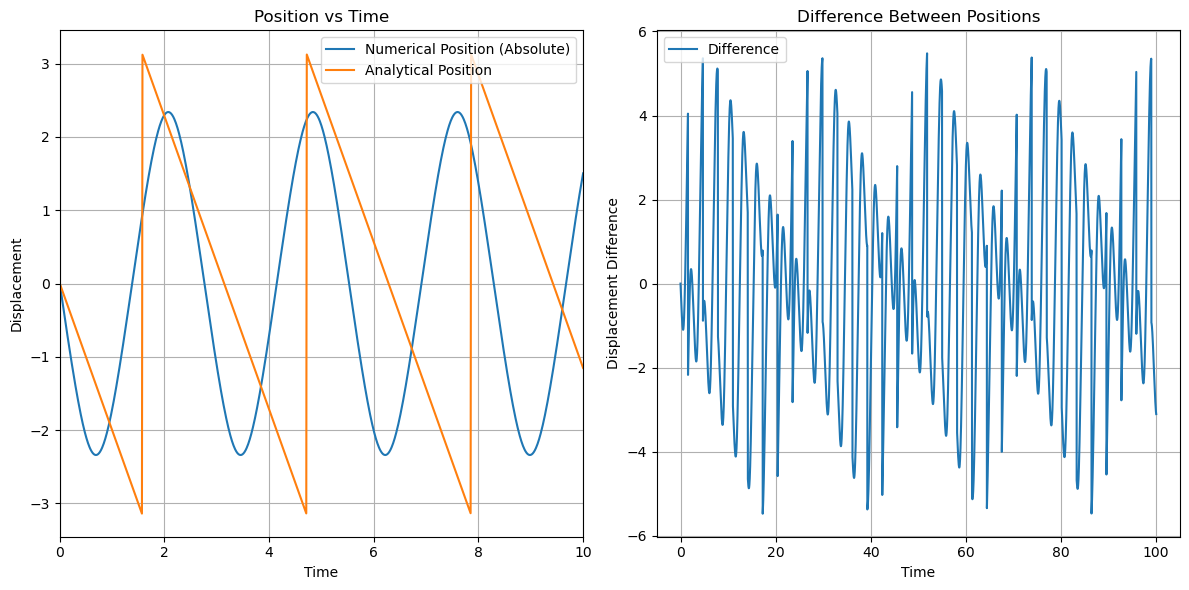

In [14]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(t, v_numeric, label='Numerical Position (Absolute)')
plt.plot(t, v_analytic, label='Analytical Position')
plt.xlabel('Time')
plt.xlim(0,10)
plt.ylabel('Displacement')
plt.title('Position vs Time')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, v_numeric - v_analytic, label='Difference')
plt.xlabel('Time')
plt.ylabel('Displacement Difference')
plt.title('Difference Between Positions')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# Variable Step Size

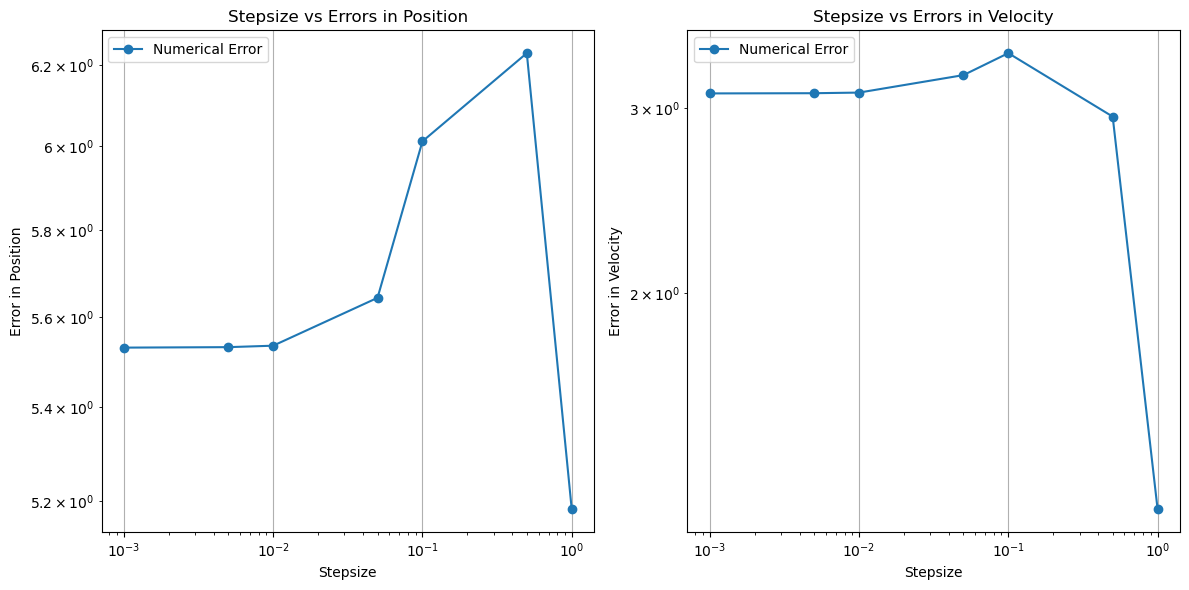

In [15]:
x0 = 1
v0 = 0
x_s = 1
t_final = 100

def analytic(t):
    v = -(2 * np.cos(t) * np.arcsin(np.sin(t)))/(np.sqrt(1-np.sin(t)**2))
    x = (2 * np.pi - np.arcsin(np.sin(t))**2)
    # x = (x - np.min(x)) / (np.max(x) - np.min(x))  # Normalize x
    # v = (v - np.min(v)) / (np.max(v) - np.min(v))  # Normalize v
    return x, v

def force(x, x_s):
    return -const.g * 2/np.pi * np.arctan(x/x_s)

def numeric(x0, v0, x_s, dt, N):
    x = np.zeros(N)
    v = np.zeros(N)

    x[0] = x0
    v[0] = v0

    for i in range(N-1):
        v[i+1] = v[i] + 0.5 * dt * force(x[i], x_s)
        x[i+1] = x[i] + dt * v[i+1]
        v[i+1] = v[i+1] + 0.5 * dt * force(x[i+1], x_s)

    return x, v

stepsizes = [1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]
errors_position = []
errors_velocity = []

for h in stepsizes:
    N = int(t_final / h) + 1
    t = np.linspace(0, t_final, N)
    dt = t[1] - t[0]
    
    x_analytic, v_analytic = analytic(t)
    x_numeric, v_numeric = numeric(x0, v0, x_s, dt, N)

    error_x = np.abs(x_numeric - x_analytic)[-1]
    error_v = np.abs(v_numeric - v_analytic)[-1]
    errors_position.append(error_x)
    errors_velocity.append(error_v)

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.plot(stepsizes, errors_position, label = 'Numerical Error', marker = 'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Position')
plt.title('Stepsize vs Errors in Position')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(stepsizes, errors_velocity, label = 'Numerical Error', marker = 'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Stepsize")
plt.ylabel('Error in Velocity')
plt.title('Stepsize vs Errors in Velocity')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()